In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Solución para caracteres especiales en español
plt.rcParams['font.family'] = 'DejaVu Sans'
import warnings
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv(r'C:\Users\kevde\proyecto_internet\data\internet_colombia.csv', 
                 encoding='latin-1')

# Renombrar columnas
df.columns = ['año', 'trimestre', 'proveedor', 'cod_departamento', 
              'departamento', 'cod_municipio', 'municipio', 
              'segmento', 'tecnologia', 'velocidad_bajada', 
              'velocidad_subida', 'accesos']

# Corregir nombres con caracteres especiales
reemplazos = {
    'BOGOT D.C.': 'BOGOTÁ D.C.',
    'BOLVAR': 'BOLÍVAR',
    'ATLNTICO': 'ATLÁNTICO',
    'QUINDO': 'QUINDÍO',
    'NARIO': 'NARIÑO',
}
df['departamento'] = df['departamento'].replace(reemplazos)
df['municipio'] = df['municipio'].replace(reemplazos)

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(df.head())

Filas: 2795052
Columnas: 12
    año  trimestre                                proveedor  cod_departamento  \
0  2018          1                              EDATEL S.A.               5.0   
1  2019          1    AXESS NETWORKS SOLUTIONS COLOMBIA SAS              52.0   
2  2019          1                     TELMEX COLOMBIA S.A.              25.0   
3  2019          1  COLOMBIA TELECOMUNICACIONES S.A. E.S.P.               8.0   
4  2020          2      SINERGY SOLUCIONES INTEGRALES S.A.S              41.0   

   departamento  cod_municipio              municipio  \
0     ANTIOQUIA         5042.0  SANTAFÃ DE ANTIOQUIA   
1       NARIÃO        52473.0               MOSQUERA   
2  CUNDINAMARCA        25269.0            FACATATIVÃ   
3    ATLÃNTICO         8685.0           SANTO TOMÃS   
4         HUILA        41551.0               PITALITO   

                  segmento tecnologia velocidad_bajada velocidad_subida  \
0              CORPORATIVO       XDSL             8,00             

In [14]:
# Ver nombres exactos de columnas
print("Columnas:")
print(df.columns.tolist())

# Ver tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

# Ver valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

Columnas:
['año', 'trimestre', 'proveedor', 'cod_departamento', 'departamento', 'cod_municipio', 'municipio', 'segmento', 'tecnologia', 'velocidad_bajada', 'velocidad_subida', 'accesos']

Tipos de datos:
año                   int64
trimestre             int64
proveedor            object
cod_departamento    float64
departamento         object
cod_municipio       float64
municipio            object
segmento             object
tecnologia           object
velocidad_bajada     object
velocidad_subida     object
accesos               int64
dtype: object

Valores nulos por columna:
año                  0
trimestre            0
proveedor            0
cod_departamento     5
departamento         0
cod_municipio       10
municipio            0
segmento             0
tecnologia           0
velocidad_bajada     0
velocidad_subida     0
accesos              0
dtype: int64


In [15]:
# Renombrar columnas para trabajar fácil
df.columns = ['año', 'trimestre', 'proveedor', 'cod_departamento', 
              'departamento', 'cod_municipio', 'municipio', 
              'segmento', 'tecnologia', 'velocidad_bajada', 
              'velocidad_subida', 'accesos']

# Corregir encoding de nombres de departamentos
df['departamento'] = df['departamento'].str.encode('latin-1').str.decode('utf-8', errors='ignore')
# Ver años disponibles en el dataset
print("\nAños disponibles:")
print(sorted(df['año'].unique()))

# Ver departamentos únicos
print(f"\nTotal departamentos: {df['departamento'].nunique()}")

# Ver tecnologías disponibles
print("\nTecnologías:")
print(df['tecnologia'].unique())


Años disponibles:
[np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Total departamentos: 34

Tecnologías:
['XDSL' 'SATELITAL' 'CABLE' 'WIFI'
 'OTRAS TECNOLOGÃ\x8dAS DE FIBRA (ANTES FTTX)'
 'HYBRID FIBER COAXIAL (HFC)'
 'FIBER TO THE BUILDING O FIBER TO THE BASEMENT (FTTB)'
 'FIBER TO THE HOME (FTTH)' 'OTRAS TECNOLOGÃ\x8dAS INALÃ\x81MBRICAS'
 'FIBER TO THE CABINET (FTTC)' 'OTRAS TECNOLOGÃ\x8dAS FIJAS' 'WIMAX'
 'FIBER TO THE PREMISES' 'FIBER TO THE ANTENNA (FTTA)'
 'FIBER TO THE NODE (FTTN)' 'NA (NO APLICA)']


In [16]:
# Simplificar nombres de tecnologías
def simplificar_tecnologia(tech):
    if 'FIBRA' in tech or 'FIBER' in tech or 'FTT' in tech:
        return 'FIBRA ÓPTICA'
    elif 'CABLE' in tech or 'HFC' in tech:
        return 'CABLE'
    elif 'XDSL' in tech:
        return 'XDSL'
    elif 'SATELITAL' in tech:
        return 'SATELITAL'
    elif 'WIFI' in tech or 'WIMAX' in tech:
        return 'WIFI/WIMAX'
    else:
        return 'OTRAS'

df['tecnologia_simple'] = df['tecnologia'].apply(simplificar_tecnologia)

print("Tecnologías simplificadas:")
print(df['tecnologia_simple'].value_counts())

Tecnologías simplificadas:
tecnologia_simple
FIBRA ÓPTICA    1056405
CABLE            639283
XDSL             510367
OTRAS            287873
SATELITAL        174319
WIFI/WIMAX       126805
Name: count, dtype: int64


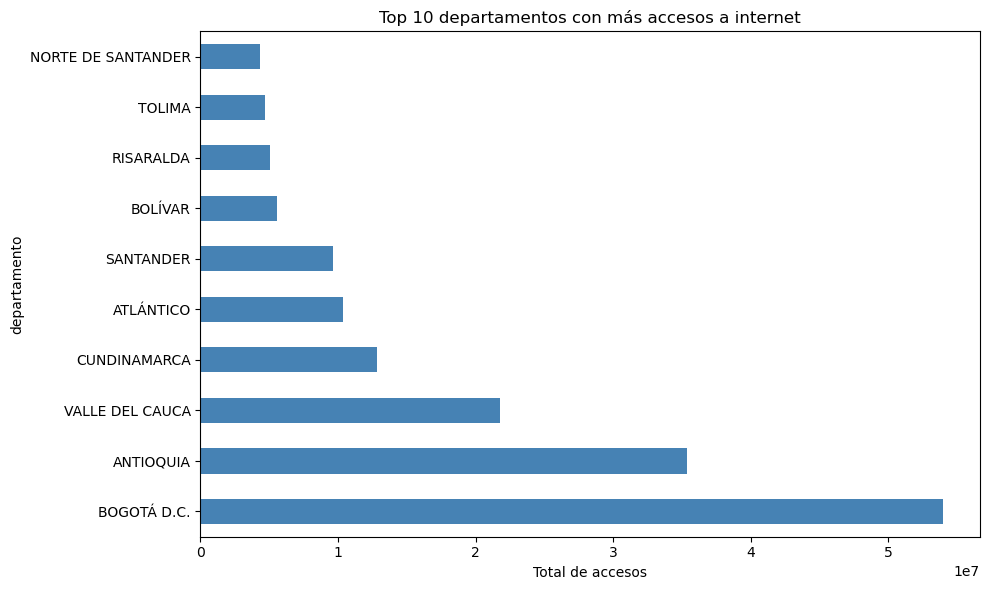

In [17]:
top_deptos = df.groupby('departamento')['accesos'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_deptos.plot(kind='barh', color='steelblue')
plt.title('Top 10 departamentos con más accesos a internet')
plt.xlabel('Total de accesos')
plt.tight_layout()
plt.savefig('graficas/top10_departamentos.png', dpi=150)
plt.show()

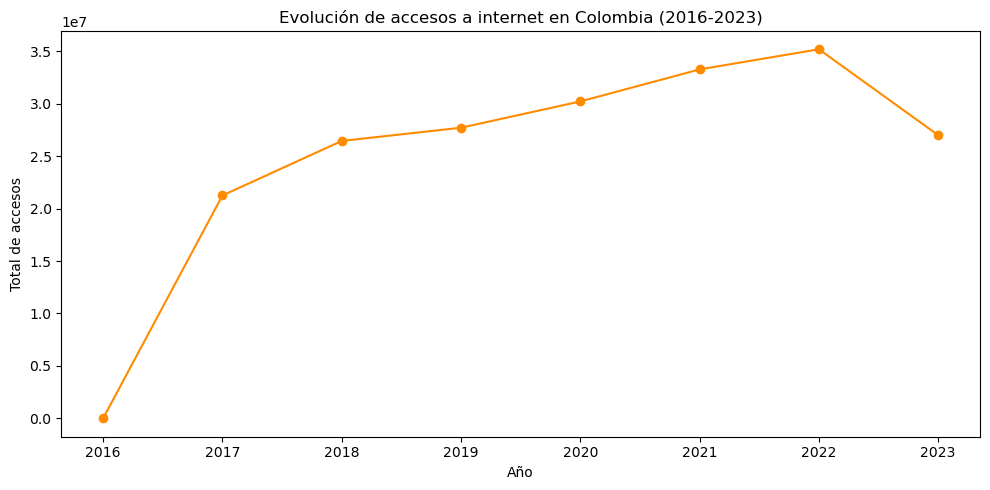

In [18]:
accesos_año = df.groupby('año')['accesos'].sum()

plt.figure(figsize=(10, 5))
accesos_año.plot(kind='line', color='darkorange', marker='o')
plt.title('Evolución de accesos a internet en Colombia (2016-2023)')
plt.ylabel('Total de accesos')
plt.xlabel('Año')
plt.tight_layout()
plt.savefig('graficas/evolucion_accesos.png', dpi=150)
plt.show()

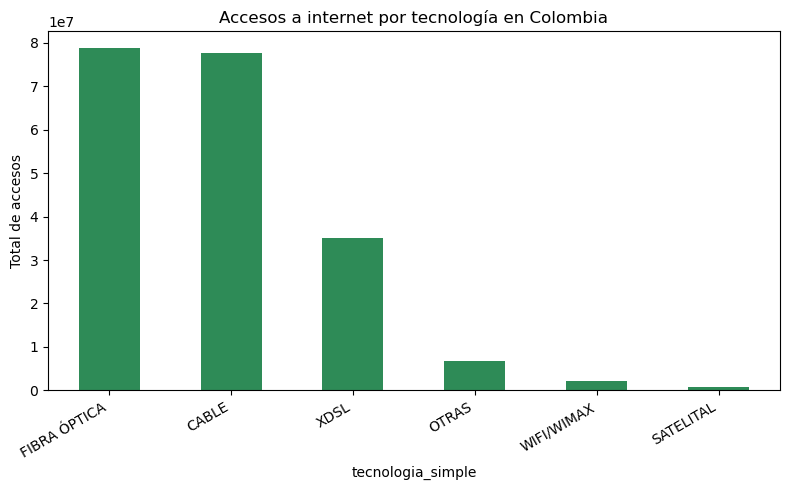

In [19]:
tech_total = df.groupby('tecnologia_simple')['accesos'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
tech_total.plot(kind='bar', color='seagreen')
plt.title('Accesos a internet por tecnología en Colombia')
plt.ylabel('Total de accesos')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('graficas/tecnologias.png', dpi=150)
plt.show()

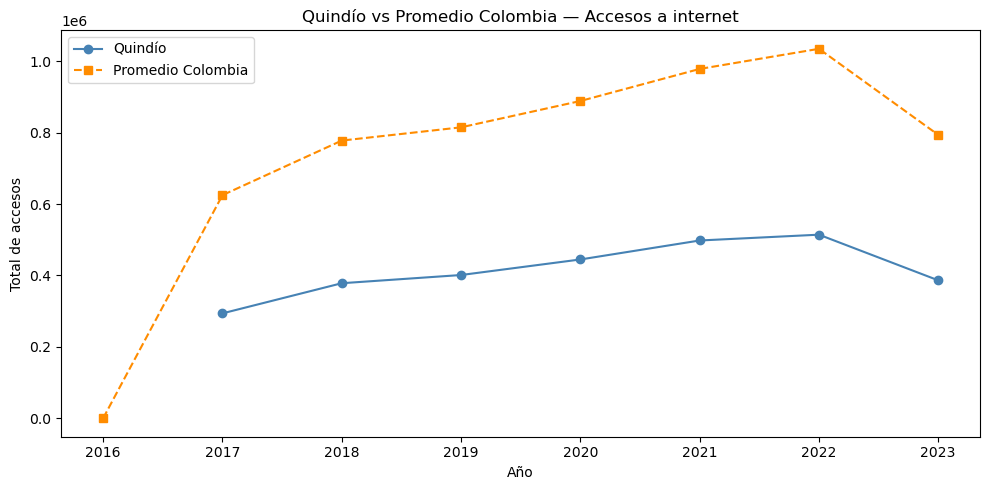

In [20]:
quindio = df[df['departamento'].str.contains('QUIN', na=False)]
quindio_año = quindio.groupby('año')['accesos'].sum()

colombia_año = df.groupby('año')['accesos'].sum()
promedio_año = colombia_año / df['departamento'].nunique()

plt.figure(figsize=(10, 5))
plt.plot(quindio_año.index, quindio_año.values, marker='o', label='Quindío', color='steelblue')
plt.plot(promedio_año.index, promedio_año.values, marker='s', label='Promedio Colombia', color='darkorange', linestyle='--')
plt.title('Quindío vs Promedio Colombia — Accesos a internet')
plt.ylabel('Total de accesos')
plt.xlabel('Año')
plt.legend()
plt.tight_layout()
plt.savefig('graficas/quindio_vs_colombia.png', dpi=150)
plt.show()

In [21]:
# Departamento con más accesos
top1 = df.groupby('departamento')['accesos'].sum().idxmax()
top1_valor = df.groupby('departamento')['accesos'].sum().max()

# Tecnología predominante
tech_top = df.groupby('tecnologia_simple')['accesos'].sum().idxmax()

# Crecimiento total
accesos_2016 = df[df['año'] == 2016]['accesos'].sum()
accesos_2023 = df[df['año'] == 2023]['accesos'].sum()
crecimiento = ((accesos_2023 - accesos_2016) / accesos_2016 * 100)

# Quindío ranking — corregido para encoding
ranking = df.groupby('departamento')['accesos'].sum().sort_values(ascending=False)
nombre_quindio = df[df['departamento'].str.contains('QUIN', na=False)]['departamento'].unique()[0]
pos_quindio = ranking.index.tolist().index(nombre_quindio) + 1

print(f"Departamento con más accesos: {top1} ({top1_valor:,})")
print(f"Tecnología predominante: {tech_top}")
print(f"Crecimiento 2016-2023: {crecimiento:.1f}%")
print(f"Posición Quindío en Colombia: #{pos_quindio} de 34")

Departamento con más accesos: BOGOTÁ D.C. (53,957,365)
Tecnología predominante: FIBRA ÓPTICA
Crecimiento 2016-2023: 5830556.6%
Posición Quindío en Colombia: #16 de 34


In [22]:
# Quindío ranking
ranking = df.groupby('departamento')['accesos'].sum().sort_values(ascending=False)
nombre_quindio = df[df['departamento'].str.contains('QUIN', na=False)]['departamento'].unique()[0]
pos_quindio = ranking.index.tolist().index(nombre_quindio) + 1